In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tulikakarmokar/wine-quality-prediction")

print("Path to dataset files:", path)

100%|██████████| 24.1k/24.1k [00:00<00:00, 29.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/tulikakarmokar/wine-quality-prediction/versions/1


In [ ]:
import os
df = pd.read_csv('/content/QualityPrediction.csv')
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [ ]:
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [ ]:
df.shape

(1599, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [ ]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
df.duplicated().sum()

np.int64(240)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

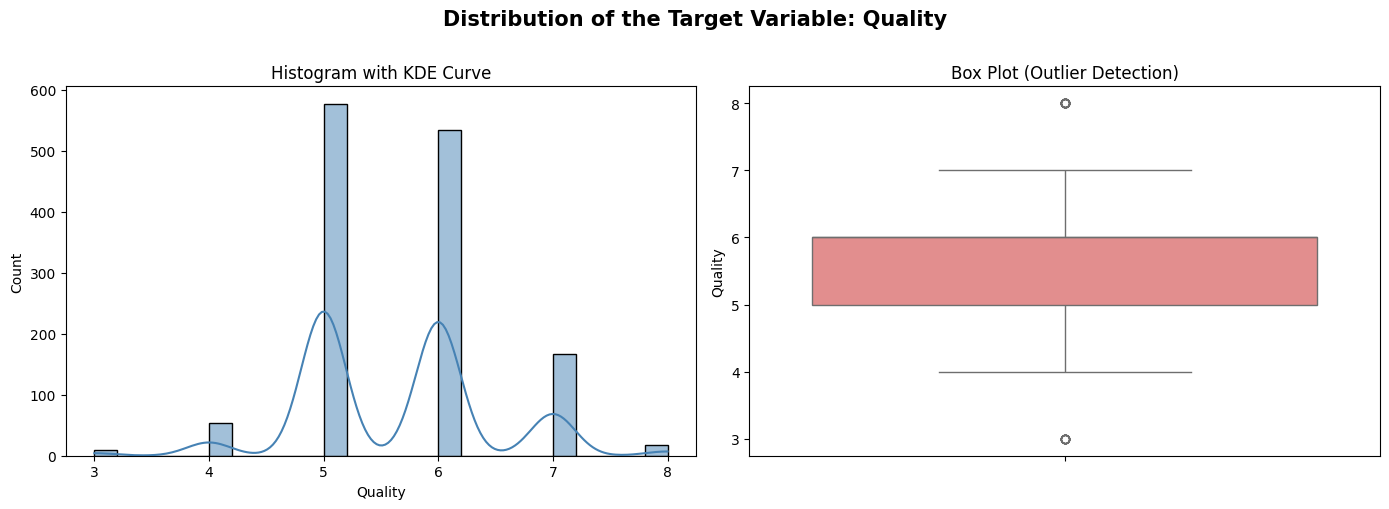

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution of the Target Variable: Quality', fontsize=15, fontweight='bold', y=1.01)


# histogram for quality
sns.histplot(df['quality'], kde=True, color='steelblue', ax=axes[0], bins=25)
axes[0].set_title('Histogram with KDE Curve')
axes[0].set_xlabel('Quality')
axes[0].set_ylabel('Count')


# boxplot for quality
sns.boxplot(y=df['quality'], color='lightcoral', ax=axes[1])
axes[1].set_title('Box Plot (Outlier Detection)')

axes[1].set_ylabel('Quality')

plt.tight_layout()
plt.show()

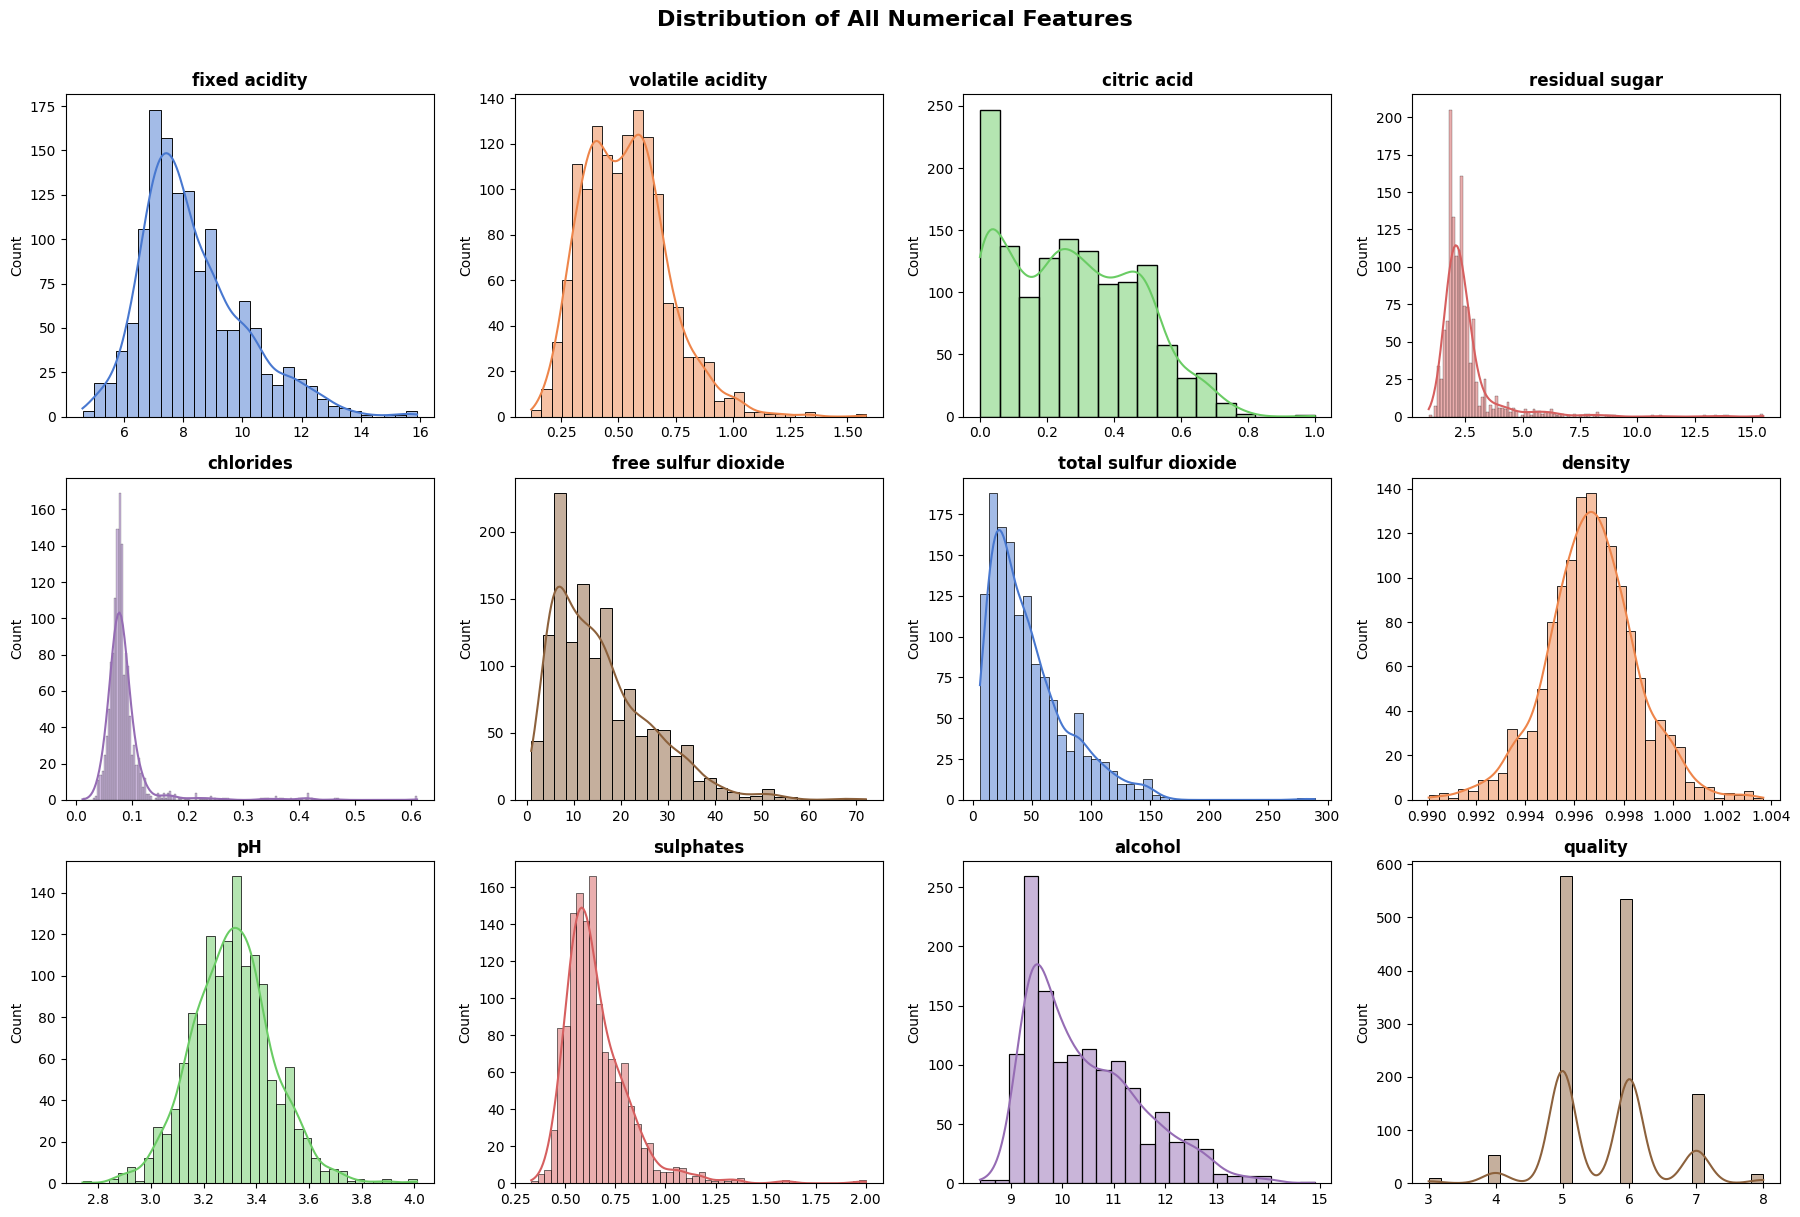

In [ ]:
# histplot for numeric values
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

n_cols  = 4
n_rows  = (len(numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
fig.suptitle('Distribution of All Numerical Features', fontsize=16, fontweight='bold', y=1.01)

axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color=sns.color_palette('muted')[i % 6])
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

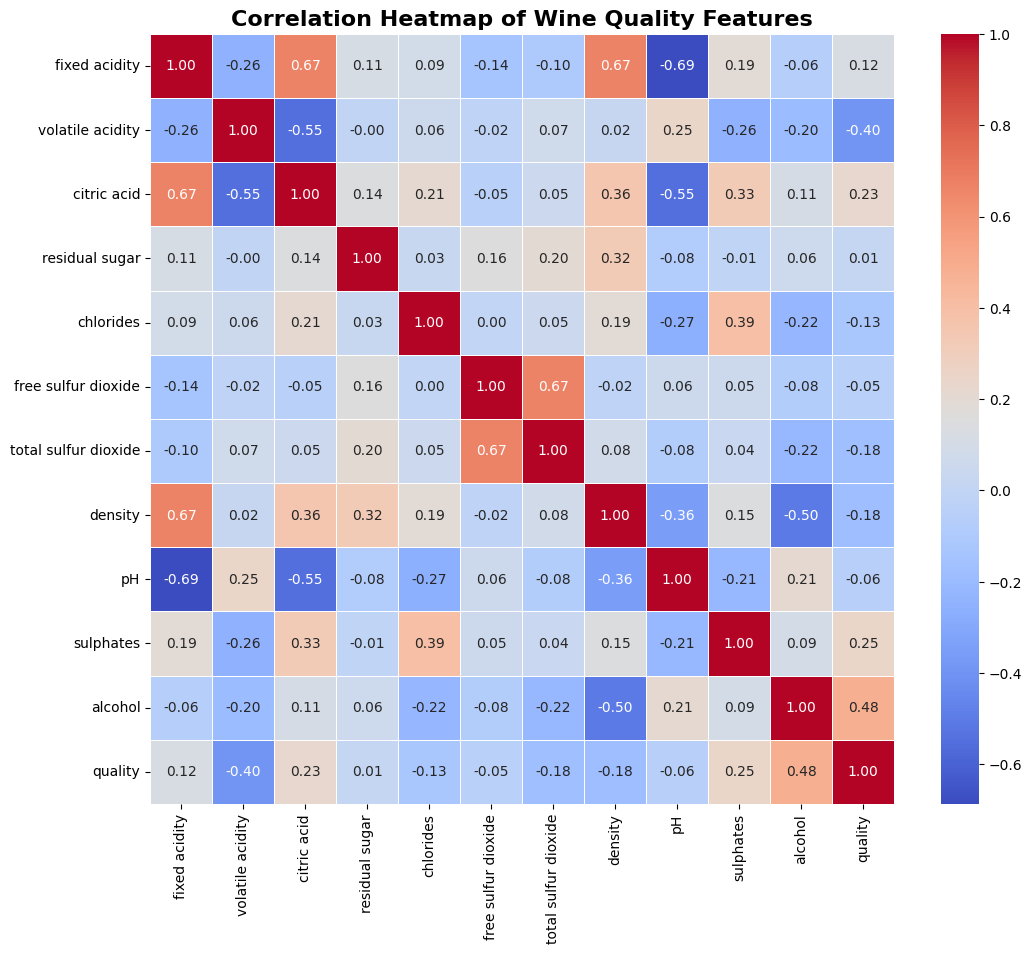

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Wine Quality Features', fontsize=16, fontweight='bold')
plt.show()

/tmp/ipykernel_1591/4273593091.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y=col, data=df, ax=axes[i], palette='viridis')
/tmp/ipykernel_1591/4273593091.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y=col, data=df, ax=axes[i], palette='viridis')
/tmp/ipykernel_1591/4273593091.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y=col, data=df, ax=axes[i], palette='viridis')
/tmp/ipykernel_1591/4273593091.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will

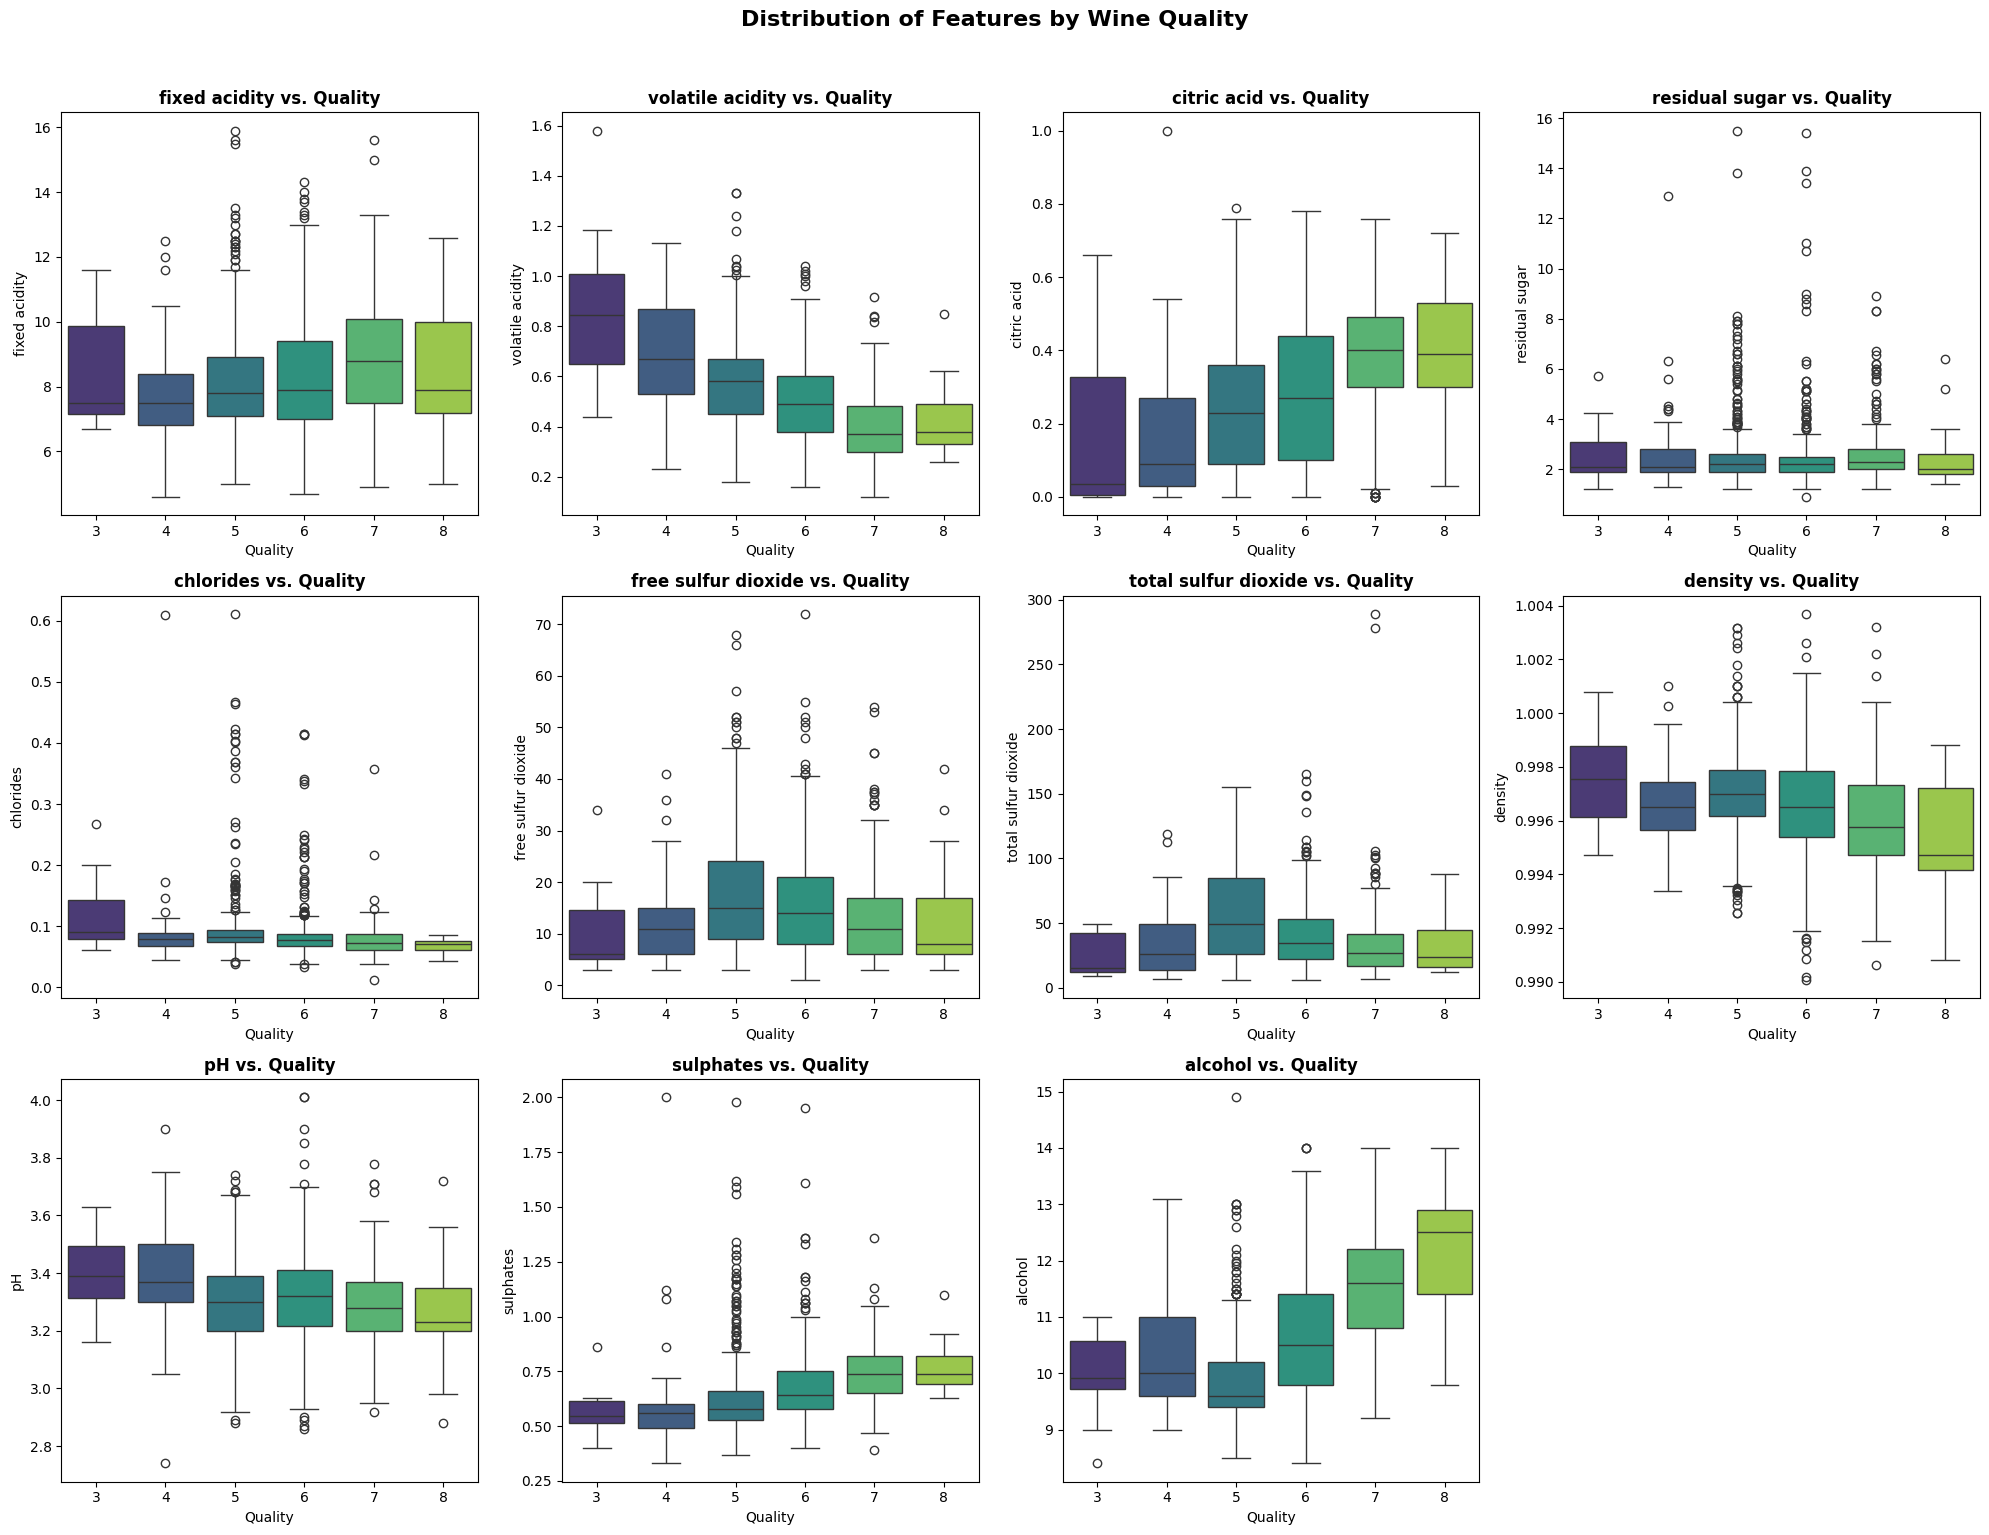

In [ ]:

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
fig.suptitle('Distribution of Features by Wine Quality', fontsize=16, fontweight='bold', y=1.02)
axes = axes.flatten()

numerical_features_for_y_axis = [col for col in df.columns if df[col].dtype in ['float64', 'int64'] and col != 'quality']

for i, col in enumerate(numerical_features_for_y_axis):
    sns.boxplot(x='quality', y=col, data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col} vs. Quality', fontweight='bold')
    axes[i].set_xlabel('Quality')
    axes[i].set_ylabel(col)

# Hide any unused subplots if the number of features is less than the total subplots
for j in range(len(numerical_features_for_y_axis), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
scaler = StandardScaler()
features_to_scale = df.columns.drop('quality')
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])
df.head()

/tmp/ipykernel_1591/3098427043.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[features_to_scale] = scaler.fit_transform(df[features_to_scale])


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,-0.524431,0.932000,-1.393258,-0.461157,-0.245623,-0.468554,-0.384050,0.584003,1.291872,-0.578561,-0.954374,5
1,-0.294063,1.915800,-1.393258,0.056665,0.200094,0.872003,0.604073,0.048737,-0.708395,0.124822,-0.584575,5
2,-0.294063,1.259934,-1.188617,-0.165259,0.078535,-0.085537,0.214813,0.155790,-0.321247,-0.051024,-0.584575,5
3,1.664067,-1.363534,1.471711,-0.461157,-0.265883,0.105971,0.394471,0.691057,-0.966495,-0.461331,-0.584575,6
5,-0.524431,0.713378,-1.393258,-0.535132,-0.265883,-0.277045,-0.204391,0.584003,1.291872,-0.578561,-0.954374,5


/tmp/ipykernel_1591/649887799.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


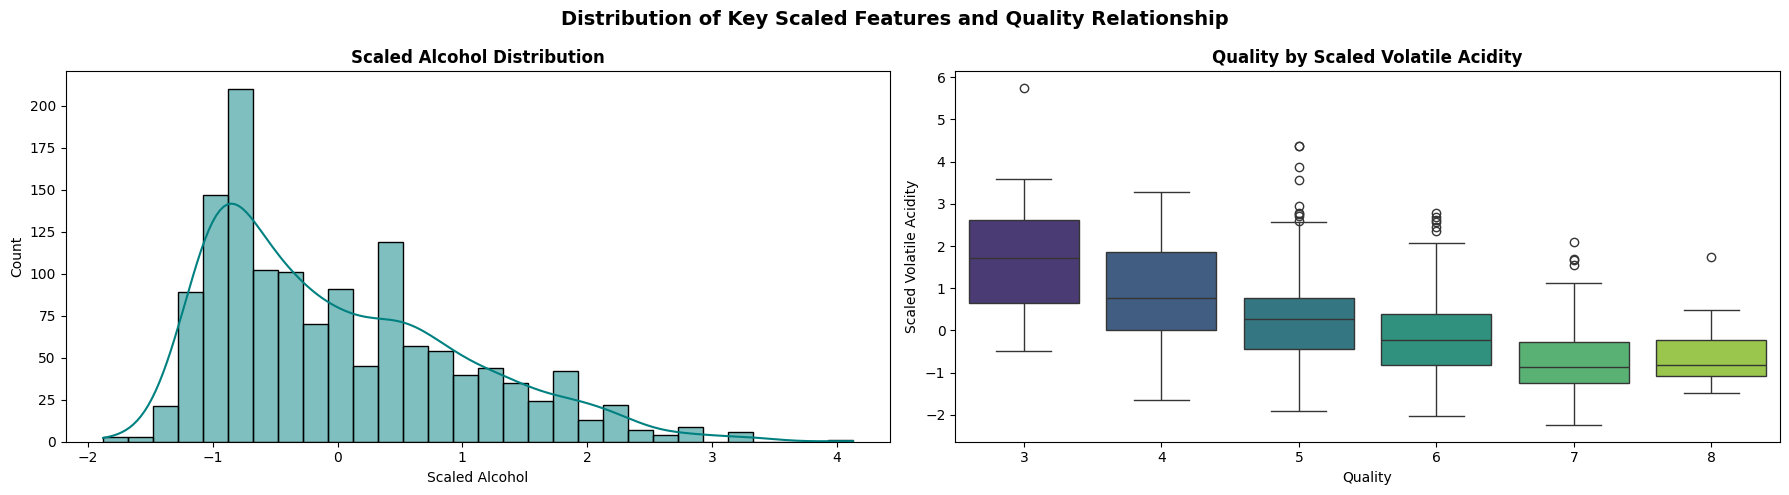

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Distribution of Key Scaled Features and Quality Relationship', fontsize=14, fontweight='bold')

sns.histplot(df['alcohol'], kde=True, color='teal', ax=axes[0], bins=30)
axes[0].set_title('Scaled Alcohol Distribution', fontweight='bold')
axes[0].set_xlabel('Scaled Alcohol')
axes[0].set_ylabel('Count')

sns.boxplot(
    data=df, x='quality', y='volatile acidity',
    palette='viridis', ax=axes[1]
)
axes[1].set_title('Quality by Scaled Volatile Acidity', fontweight='bold')
axes[1].set_xlabel('Quality')
axes[1].set_ylabel('Scaled Volatile Acidity')

plt.tight_layout()
plt.show()

In [ ]:
X = df.drop(['quality', 'fixed acidity', 'citric acid'], axis=1)
y = df['quality']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1),
    "Lasso Regression": Lasso(alpha=0.1),
    "Decision Tree Regression": DecisionTreeRegressor(),
    "Random Forest Regression": RandomForestRegressor(n_estimators=150),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    "Linear SVM": SVR(kernel='linear', C=100, epsilon=0.1),
    "RBF SVM": SVR(kernel='rbf', C=100, gamma=0.1),
    "Polynomial SVM": SVR(kernel='poly', C=100, degree=2),
    "Sigmoid SVM": SVR(kernel='sigmoid', C=100, gamma='scale')
}

In [ ]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test,y_pred)

    results.append([name,mse,r2])

In [ ]:
result_df = pd.DataFrame(results,columns=['Model','MSE','R2'])
print(result_df)

                      Model           MSE            R2
0         Linear Regression  4.649751e-01  2.884769e-01
1          Ridge Regression  4.649524e-01  2.885116e-01
2          Lasso Regression  4.880297e-01  2.531979e-01
3  Decision Tree Regression  8.125000e-01 -2.433193e-01
4  Random Forest Regression  4.110219e-01  3.710382e-01
5       K-Nearest Neighbors  4.494118e-01  3.122925e-01
6                Linear SVM  4.808794e-01  2.641396e-01
7                   RBF SVM  5.908275e-01  9.589267e-02
8            Polynomial SVM  6.610706e-01 -1.159605e-02
9               Sigmoid SVM  1.227093e+06 -1.877745e+06


In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1),
    "Lasso Regression": Lasso(alpha=0.1),
    "Decision Tree Regression": DecisionTreeRegressor(),
    "Random Forest Regression": RandomForestRegressor(n_estimators=150),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
}

In [ ]:
from sklearn.ensemble import StackingRegressor

stack_model = StackingRegressor(
    estimators=[
        ('lr',models['Linear Regression']),
        ('ridge',models['Ridge Regression']),
        ('lasso',models['Lasso Regression']),
        ('dt',models['Decision Tree Regression']),
        ('knn',models['K-Nearest Neighbors'])
    ],
    final_estimator=models['Random Forest Regression']
)
stack_model.fit(X_train, y_train)

StackingRegressor(estimators=[('lr', LinearRegression()),
                              ('ridge', Ridge(alpha=1)),
                              ('lasso', Lasso(alpha=0.1)),
                              ('dt', DecisionTreeRegressor()),
                              ('knn', KNeighborsRegressor())],
                  final_estimator=RandomForestRegressor(n_estimators=150))

In [ ]:
y_pred = stack_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)
results.append(['Stacking',mse,r2])
print(f"MSE: {mse}")
print(f"R2: {r2}")

MSE: 0.49386078431372543
R2: 0.2442749179559307


In [ ]:
from sklearn.ensemble import VotingRegressor

vote_model = VotingRegressor(
    estimators=[
        ('lr',models['Linear Regression']),
        ('ridge',models['Ridge Regression']),
        ('lasso',models['Lasso Regression']),
        ('dt',models['Decision Tree Regression']),
        ('knn',models['K-Nearest Neighbors']),
        ('rf',models['Random Forest Regression'])
    ]
)

vote_model.fit(X_train,y_train)

VotingRegressor(estimators=[('lr', LinearRegression()),
                            ('ridge', Ridge(alpha=1)),
                            ('lasso', Lasso(alpha=0.1)),
                            ('dt', DecisionTreeRegressor()),
                            ('knn', KNeighborsRegressor()),
                            ('rf', RandomForestRegressor(n_estimators=150))])

In [ ]:
y_pred = vote_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)
results.append(['Voting',mse,r2])
print(f"MSE: {mse}")
print(f"R2: {r2}")

MSE: 0.427555947197605
R2: 0.3457371722208239


In [ ]:
results_df = pd.DataFrame(results,columns=['Model','MSE','R2'])
print(results_df)

                       Model           MSE            R2
0          Linear Regression  4.649751e-01  2.884769e-01
1           Ridge Regression  4.649524e-01  2.885116e-01
2           Lasso Regression  4.880297e-01  2.531979e-01
3   Decision Tree Regression  8.125000e-01 -2.433193e-01
4   Random Forest Regression  4.110219e-01  3.710382e-01
5        K-Nearest Neighbors  4.494118e-01  3.122925e-01
6                 Linear SVM  4.808794e-01  2.641396e-01
7                    RBF SVM  5.908275e-01  9.589267e-02
8             Polynomial SVM  6.610706e-01 -1.159605e-02
9                Sigmoid SVM  1.227093e+06 -1.877745e+06
10                  Stacking  4.938608e-01  2.442749e-01
11                    Voting  4.275559e-01  3.457372e-01


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
non_nan_mask_train = ~y_train.isna()
X_train_cleaned = X_train[non_nan_mask_train.to_numpy()]
y_train_cleaned = y_train[non_nan_mask_train]
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

nb_model = GaussianNB()
lr_model = LogisticRegression(random_state=42, max_iter=200, solver='liblinear')
dt_model = DecisionTreeClassifier(random_state=42)

nb_model.fit(X_train_cleaned, y_train_cleaned)
lr_model.fit(X_train_cleaned, y_train_cleaned)
dt_model.fit(X_train_cleaned, y_train_cleaned)

DecisionTreeClassifier(random_state=42)

In [ ]:

from sklearn.metrics import accuracy_score, confusion_matrix

models = {
    "Naive Bayes": nb_model,
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model
}

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")


Naive Bayes Accuracy: 0.5588
Logistic Regression Accuracy: 0.6029
Decision Tree Accuracy: 0.4596


In [ ]:
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("\nBest Model:", best_model_name)


Best Model: Logistic Regression


In [ ]:
from sklearn.metrics import classification_report

y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00        11
           5       0.66      0.79      0.72       120
           6       0.54      0.64      0.58       103
           7       0.50      0.10      0.16        31
           8       0.00      0.00      0.00         3

    accuracy                           0.60       272
   macro avg       0.28      0.25      0.24       272
weighted avg       0.55      0.60      0.56       272



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
best_model = RandomForestRegressor(n_estimators=150)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)

print(f"MSE: {mse}")
print(f"R2: {r2}")

MSE: 0.38800588235294114
R2: 0.45224441009788774


In [ ]:
import pickle
pickle.dump(best_model,open("RandomForest_model1.pkl","wb"))
pickle.dump(scaler,open("RandomForest_scaler1.pkl","wb"))

In [ ]:
import gradio as gr
import numpy as np
import pickle

# Load model and scaler
model = pickle.load(open("RandomForest_model1.pkl", "rb"))
scaler = pickle.load(open("RandomForest_scaler1.pkl", "rb"))

# Prediction function
def predict_wine_quality(volatile_acidity, residual_sugar, chlorides,
                         free_sulfur_dioxide, total_sulfur_dioxide,
                         density, pH, sulphates, alcohol):

    data = np.array([[volatile_acidity, residual_sugar, chlorides,
                      free_sulfur_dioxide, total_sulfur_dioxide,
                      density, pH, sulphates, alcohol]])

    data = scaler.transform(data)
    result = model.predict(data)

    return f"Predicted Wine Quality: {result[0]:.2f}"

# Gradio Interface
demo = gr.Interface(
    fn=predict_wine_quality,
    inputs=[
        gr.Number(label="Volatile Acidity"),
        gr.Number(label="Residual Sugar"),
        gr.Number(label="Chlorides"),
        gr.Number(label="Free Sulfur Dioxide"),
        gr.Number(label="Total Sulfur Dioxide"),
        gr.Number(label="Density"),
        gr.Number(label="pH"),
        gr.Number(label="Sulphates"),
        gr.Number(label="Alcohol")
    ],
    outputs=gr.Textbox(label="Prediction"),
    title="Wine Quality Prediction ",
    description="Enter the chemical properties of wine to predict its quality (0–10 scale)."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d9763e1d9dad087cdb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
!pip install streamlit

In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import pickle

# Load model and scaler
# Ensure these files are in the working directory or provide their full path
model = pickle.load(open("RandomForest_model1.pkl", "rb"))
scaler = pickle.load(open("RandomForest_scaler1.pkl", "rb"))

# App title
st.title(" Wine Quality Prediction")
st.write("Enter the chemical properties of wine to predict its quality (0–10 scale).")

# Input fields
volatile_acidity = st.number_input("Volatile Acidity", min_value=0.0)
residual_sugar = st.number_input("Residual Sugar", min_value=0.0)
chlorides = st.number_input("Chlorides", min_value=0.0)
free_sulfur_dioxide = st.number_input("Free Sulfur Dioxide", min_value=0.0)
total_sulfur_dioxide = st.number_input("Total Sulfur Dioxide", min_value=0.0)
density = st.number_input("Density", min_value=0.0)
pH = st.number_input("pH", min_value=0.0)
sulphates = st.number_input("Sulphates", min_value=0.0)
alcohol = st.number_input("Alcohol", min_value=0.0)

# Prediction function
def predict():
    data = np.array([[volatile_acidity, residual_sugar, chlorides,
                      free_sulfur_dioxide, total_sulfur_dioxide,
                      density, pH, sulphates, alcohol]])

    data_scaled = scaler.transform(data)
    result = model.predict(data_scaled)

    return result[0]

# Button
if st.button("Predict Wine Quality"):
    prediction = predict()
    st.success(f"Predicted Wine Quality: {prediction:.2f}")


# Now, execute the Streamlit app
!pip install pyngrok --quiet

from pyngrok import ngrok
import subprocess
import time

# Terminate any existing ngrok tunnels
ngrok.kill()

# Start ngrok tunnel for Streamlit on port 8501
print("Starting ngrok tunnel...")
public_url = ngrok.connect(8501)
print(f"Your Streamlit app will be available at: {public_url}")

# Run the Streamlit app in the background
print("Launching Streamlit app...")
# Use subprocess to run streamlit in a non-blocking way
process = subprocess.Popen(["streamlit", "run", "app.py"])

# Give some time for Streamlit to start
time.sleep(5)
print("Streamlit app launched. Check the URL above.")

In [ ]:
!streamlit run app.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://8.229.227.128:8501

